# CIFAR-10 Notebook

This notebook converts `Assignment_1.py` into a clean, self-contained notebook that can be run in the VS Code cluster environment.

- Data is loaded from a local `data/` folder.
- Figures are saved into an `outputs/` folder with informative filenames.
- Cells are ordered so dependencies are explicit and minimal.

In [10]:
%matplotlib inline

from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Resolve the working directory for this notebook and find the local data folder.
notebook_dir = Path.cwd()
if not (notebook_dir / "data").exists() and (notebook_dir / "deep_learning_ass1" / "data").exists():
    notebook_dir = notebook_dir / "deep_learning_ass1"

DATA_ROOT = notebook_dir / "data"
OUTPUTS_DIR = notebook_dir / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook directory:", notebook_dir)
print("Data root:", DATA_ROOT)
print("Outputs directory:", OUTPUTS_DIR)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Expected data directory not found: {DATA_ROOT}")

if not (DATA_ROOT / "cifar-10-batches-py").exists():
    raise FileNotFoundError(f"Expected CIFAR-10 batch folder not found in {DATA_ROOT}")

Using device: cuda
Notebook directory: /home/raveco/deep_learning_ass1
Data root: /home/raveco/deep_learning_ass1/data
Outputs directory: /home/raveco/deep_learning_ass1/outputs


In [11]:
def get_train_val_test_data(validation_size=5000,
                            train_transforms=transforms.ToTensor(),
                            test_transforms=transforms.ToTensor()):
    """
    Load the CIFAR10 dataset and split it into training, validation, and test sets.

    Parameters:
        validation_size (int): Number of samples to use for the validation set.
        train_transforms: Transformations to be applied to the training data.
        test_transforms: Transformations to be applied to the validation and test data.
    """

    # load the training set twice:
    # one copy with train transforms, one copy with test/validation transforms
    full_train_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=True,
        download=False,
        transform=train_transforms
    )

    full_val_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=True,
        download=False,
        transform=test_transforms
    )

    test_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=False,
        download=False,
        transform=test_transforms
    )

    total_train_size = len(full_train_dataset)
    train_size = total_train_size - validation_size

    indices = torch.randperm(total_train_size).tolist()

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = Subset(full_train_dataset, train_indices)
    val_dataset = Subset(full_val_dataset, val_indices)

    return train_dataset, val_dataset, test_dataset

In [12]:
train_dataset, val_dataset, test_dataset = get_train_val_test_data()
print("Loaded datasets:")
print("  Train images:", len(train_dataset))
print("  Validation images:", len(val_dataset))
print("  Test images:", len(test_dataset))

/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Loaded datasets:
  Train images: 45000
  Validation images: 5000
  Test images: 10000


In [13]:
def save_figure(fig, filename):
    """Save a matplotlib figure to the outputs directory."""
    output_path = OUTPUTS_DIR / filename
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path

def show_images(dataset, num_images=5, title=""): #shows images from the dataset
    """Display sample images from the dataset."""
    label_names = dataset.dataset.classes if hasattr(dataset, "dataset") else dataset.classes

    fig, axes = plt.subplots(1, num_images, figsize=(10, 3))
    fig.suptitle(title)

    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy()

        ax = axes[i] if num_images > 1 else axes
        ax.imshow(image)
        ax.set_title(label_names[label])
        ax.axis("off")

    fig.tight_layout()
    return fig

Saved figure: /home/raveco/deep_learning_ass1/outputs/train_samples.png


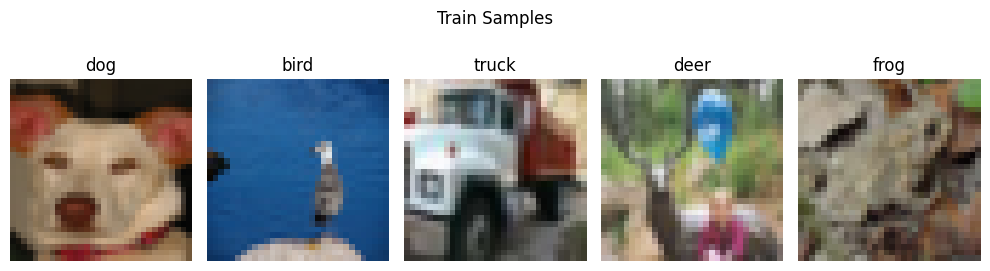

Saved figure: /home/raveco/deep_learning_ass1/outputs/validation_samples.png


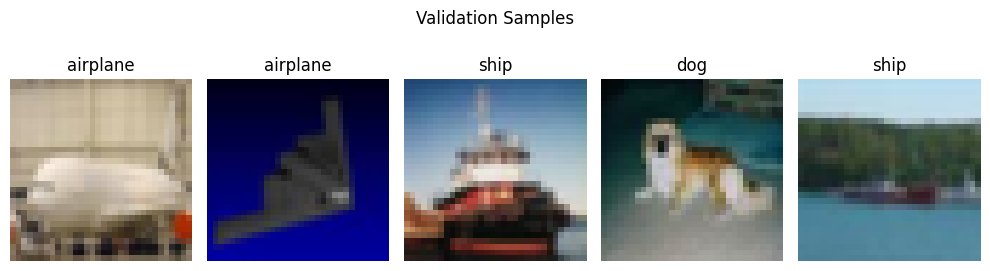

Saved figure: /home/raveco/deep_learning_ass1/outputs/test_samples.png


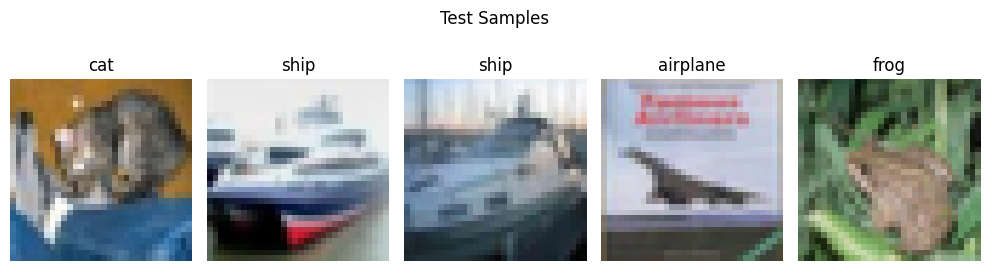

In [14]:
fig = show_images(train_dataset, 5, title="Train Samples")
save_figure(fig, "train_samples.png")
plt.show()

fig = show_images(val_dataset, 5, title="Validation Samples")
save_figure(fig, "validation_samples.png")
plt.show()

fig = show_images(test_dataset, 5, title="Test Samples")
save_figure(fig, "test_samples.png")
plt.show()

Image shape (C, H, W): torch.Size([3, 32, 32])
Label: 9

Channel-wise stats:
Red channel -> min: 0.0863, max: 1.0000, mean: 0.7916
Green channel -> min: 0.0980, max: 1.0000, mean: 0.6693
Blue channel -> min: 0.0745, max: 1.0000, mean: 0.6316
Saved figure: /home/raveco/deep_learning_ass1/outputs/debug_rgb_channels.png


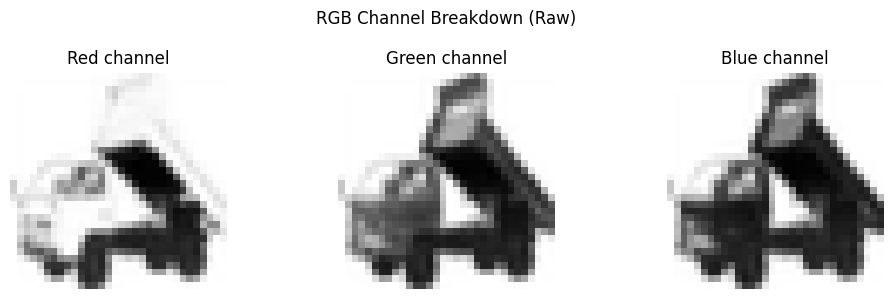

Final image array shape (H, W, C): (32, 32, 3)
Value range: 0.07450981 to 1.0
Saved figure: /home/raveco/deep_learning_ass1/outputs/debug_rgb_overlay.png


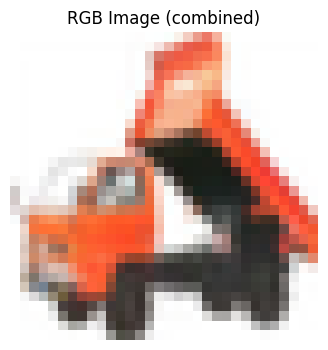

In [15]:
# ===================== DEBUG: IMAGE RGB CHECK =====================

def debug_image_rgb(dataset):
    """Debug: show individual RGB channels and statistics."""
    image, label = dataset[0]  # take first image

    print("Image shape (C, H, W):", image.shape)
    print("Label:", label)

    print("\nChannel-wise stats:")
    for i, color in enumerate(["Red", "Green", "Blue"]):
        print(f"{color} channel -> min: {image[i].min():.4f}, max: {image[i].max():.4f}, mean: {image[i].mean():.4f}")

    # show raw channels
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    for i, color in enumerate(["Red", "Green", "Blue"]):
        axs[i].imshow(image[i], cmap="gray")
        axs[i].set_title(f"{color} channel")
        axs[i].axis("off")

    fig.suptitle("RGB Channel Breakdown (Raw)")
    fig.tight_layout()
    return fig


def debug_rgb_overlay(dataset):
    """Debug: show RGB image overlay."""
    image, _ = dataset[0]

    # convert CHW → HWC for display
    img = image.permute(1, 2, 0).numpy()

    fig = plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title("RGB Image (combined)")
    plt.axis("off")

    print("Final image array shape (H, W, C):", img.shape)
    print("Value range:", img.min(), "to", img.max())
    
    return fig


# run debug
train_dataset, val_dataset, test_dataset = get_train_val_test_data()
fig_rgb = debug_image_rgb(train_dataset)
save_figure(fig_rgb, "debug_rgb_channels.png")
plt.show()

fig_overlay = debug_rgb_overlay(train_dataset)
save_figure(fig_overlay, "debug_rgb_overlay.png")
plt.show()

# ================================================================

Saved figure: /home/raveco/deep_learning_ass1/outputs/class_distribution_train_val_test.png


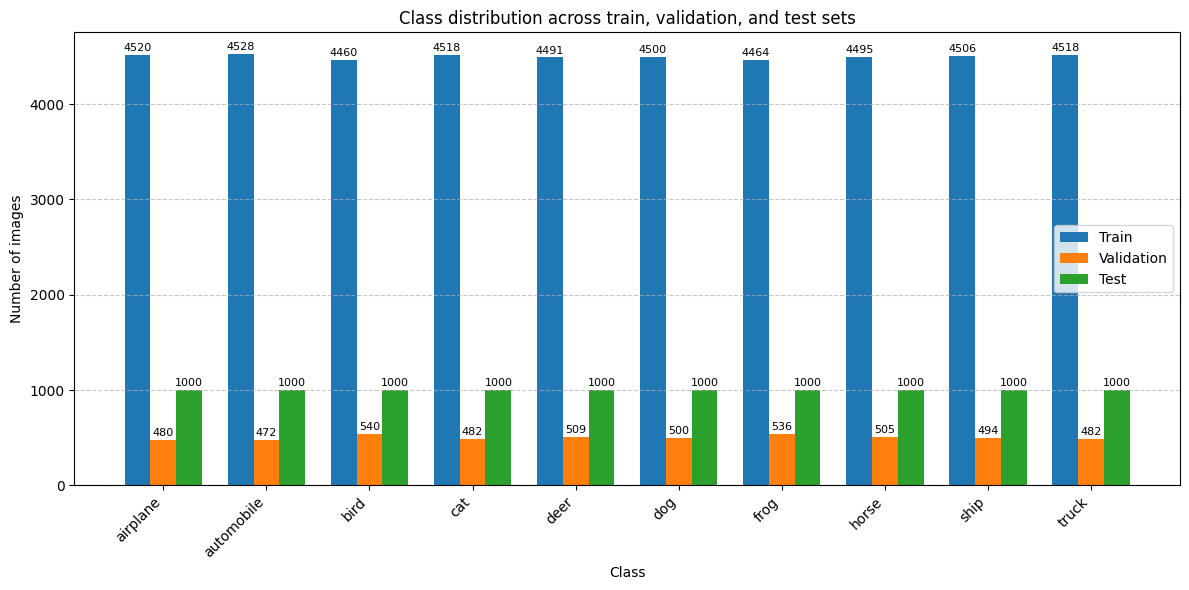

In [16]:
# ===================== PLOT CLASS DISTRIBUTION =====================

def plot_class_distribution(train_dataset, val_dataset, test_dataset):
    """Plot class distribution across train, validation, and test sets."""
    label_names = test_dataset.classes
    num_classes = len(label_names)

    train_counts = np.zeros(num_classes, dtype=int)
    val_counts = np.zeros(num_classes, dtype=int)
    test_counts = np.zeros(num_classes, dtype=int)

    # count train labels
    for idx in train_dataset.indices:
        label = train_dataset.dataset.targets[idx]
        train_counts[label] += 1

    # count validation labels
    for idx in val_dataset.indices:
        label = val_dataset.dataset.targets[idx]
        val_counts[label] += 1

    # count test labels
    for label in test_dataset.targets:
        test_counts[label] += 1

    x = np.arange(num_classes)
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))

    bars_train = ax.bar(x - bar_width, train_counts, width=bar_width, label="Train")
    bars_val = ax.bar(x, val_counts, width=bar_width, label="Validation")
    bars_test = ax.bar(x + bar_width, test_counts, width=bar_width, label="Test")

    # add numbers on top of bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 20,
                str(int(height)),
                ha='center',
                va='bottom',
                fontsize=8
            )

    add_labels(bars_train)
    add_labels(bars_val)
    add_labels(bars_test)

    ax.set_xticks(x)
    ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.set_ylabel("Number of images")
    ax.set_xlabel("Class")
    ax.set_title("Class distribution across train, validation, and test sets")

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    fig.tight_layout()
    
    return fig

train_dataset, val_dataset, test_dataset = get_train_val_test_data()
fig_dist = plot_class_distribution(train_dataset, val_dataset, test_dataset)
save_figure(fig_dist, "class_distribution_train_val_test.png")
plt.show()

Saved figure: /home/raveco/deep_learning_ass1/outputs/rgb_stats_per_class.png


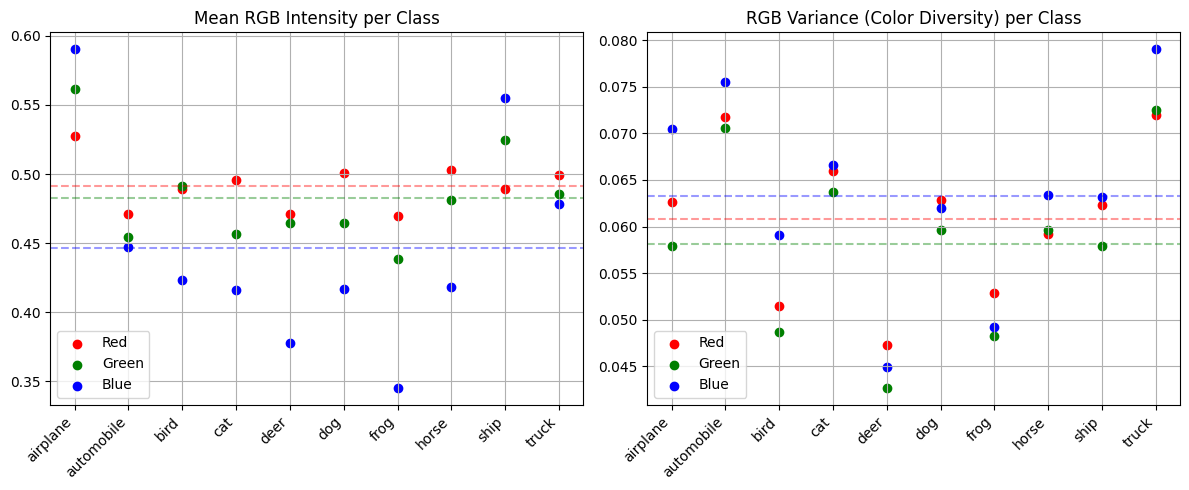

airplane:
  Mean RGB     = [0.52720165 0.5616889  0.59028536]
  Variance RGB = [0.06259835 0.05785975 0.07043427]

automobile:
  Mean RGB     = [0.4710572  0.4546824  0.44726813]
  Variance RGB = [0.07172659 0.07061034 0.0755358 ]

bird:
  Mean RGB     = [0.48901182 0.49118242 0.42326224]
  Variance RGB = [0.05142371 0.04866037 0.05906975]

cat:
  Mean RGB     = [0.49553895 0.4566008  0.41573372]
  Variance RGB = [0.06593728 0.06366138 0.06657794]

deer:
  Mean RGB     = [0.47117484 0.46462348 0.3778981 ]
  Variance RGB = [0.04731274 0.04264744 0.04488765]

dog:
  Mean RGB     = [0.5007979  0.46472183 0.41654983]
  Variance RGB = [0.06283867 0.05961725 0.06202428]

frog:
  Mean RGB     = [0.46994397 0.438645   0.34517667]
  Variance RGB = [0.0528402  0.04823418 0.04914884]

horse:
  Mean RGB     = [0.5028532  0.4810269  0.41803542]
  Variance RGB = [0.05922946 0.05959615 0.06333306]

ship:
  Mean RGB     = [0.48919037 0.52495563 0.55471444]
  Variance RGB = [0.06235486 0.05786777 0.063

In [17]:
# ===================== RGB CLASS ANALYSIS =====================

def compute_class_rgb_stats(dataset):
    """
    Computes per-class RGB mean and variance.

    Args:
        dataset: torch.utils.data.Subset (train/val)

    Returns:
        class_means: (num_classes, 3)
        class_vars: (num_classes, 3)
    """
    num_classes = len(dataset.dataset.classes)

    pixel_sum = torch.zeros(num_classes, 3)
    pixel_sq_sum = torch.zeros(num_classes, 3)
    pixel_count = torch.zeros(num_classes)

    for idx in dataset.indices:
        img, label = dataset.dataset[idx]  # (C,H,W)

        img = img.view(3, -1)  # flatten → (3, pixels)

        pixel_sum[label] += img.sum(dim=1)
        pixel_sq_sum[label] += (img ** 2).sum(dim=1)
        pixel_count[label] += img.shape[1]

    class_means = pixel_sum / pixel_count.unsqueeze(1)
    class_vars = (pixel_sq_sum / pixel_count.unsqueeze(1)) - class_means**2

    return class_means.numpy(), class_vars.numpy()


def plot_rgb_stats(class_means, class_vars, class_names):
    """Plot RGB statistics (mean and variance) per class."""
    x = np.arange(len(class_names))
    mean_R = class_means[:, 0].mean()
    mean_G = class_means[:, 1].mean()
    mean_B = class_means[:, 2].mean()

    var_R = class_vars[:, 0].mean()
    var_G = class_vars[:, 1].mean()
    var_B = class_vars[:, 2].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---- Mean ----
    axes[0].scatter(x, class_means[:, 0], color='r', label="Red")
    axes[0].scatter(x, class_means[:, 1], color='g', label="Green")
    axes[0].scatter(x, class_means[:, 2], color='b', label="Blue")
    axes[0].set_title("Mean RGB Intensity per Class")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True)

    axes[0].axhline(mean_R, color='r', linestyle='--', alpha=0.4)
    axes[0].axhline(mean_G, color='g', linestyle='--', alpha=0.4)
    axes[0].axhline(mean_B, color='b', linestyle='--', alpha=0.4)

    # ---- Variance ----
    axes[1].scatter(x, class_vars[:, 0], color='r', label="Red")
    axes[1].scatter(x, class_vars[:, 1], color='g', label="Green")
    axes[1].scatter(x, class_vars[:, 2], color='b', label="Blue")
    axes[1].set_title("RGB Variance (Color Diversity) per Class")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True)

    axes[1].axhline(var_R, color='r', linestyle='--', alpha=0.4)
    axes[1].axhline(var_G, color='g', linestyle='--', alpha=0.4)
    axes[1].axhline(var_B, color='b', linestyle='--', alpha=0.4)

    fig.tight_layout()
    return fig


# ---- RUN ANALYSIS ----
class_means, class_vars = compute_class_rgb_stats(train_dataset)
fig_rgb_stats = plot_rgb_stats(class_means, class_vars, train_dataset.dataset.classes)
save_figure(fig_rgb_stats, "rgb_stats_per_class.png")
plt.show()

# Optional: print numeric values (useful for report)
for i, cls in enumerate(train_dataset.dataset.classes):
    print(f"{cls}:")
    print(f"  Mean RGB     = {class_means[i]}")
    print(f"  Variance RGB = {class_vars[i]}")
    print()

# =============================================================

In [18]:
def train(model, optimizer, loss_fn, train_loader, val_loader=None, epochs=10, device="cuda"):
    """
    Train a neural network model and optionally evaluate its performance on validation data.

    Parameters:
        model: The neural network model to be trained.
        optimizer: The optimizer used to update the model parameters.
        loss_fn: The loss function used to compute the training loss.
        train_loader: DataLoader providing the training data in batches.
        val_loader (optional): DataLoader providing the validation data in batches.
        epochs (int): Number of training epochs.
        device (str): Device for computation (e.g., "cuda" or "cpu").
    """

    # Loop through epochs and batches.
    # For each batch, perform a forward pass, compute loss, and update the model.
    # If a validation loader is provided, evaluate the model on the validation set.
    
    model.to(device)
    history = {"train_loss": [], "val_loss": []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        history["train_loss"].append(epoch_loss)

        if val_loader is not None:
            model.eval()
            val_running_loss = 0.0
            with torch.no_grad():
                for val_inputs, val_labels in val_loader:
                    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                    val_outputs = model(val_inputs)
                    val_loss = loss_fn(val_outputs, val_labels)
                    val_running_loss += val_loss.item() * val_inputs.size(0)
            history["val_loss"].append(val_running_loss / len(val_loader.dataset))
            print(f"Epoch {epoch+1}/{epochs}: train_loss={epoch_loss:.4f}, val_loss={history['val_loss'][-1]:.4f}")
        else:
            print(f"Epoch {epoch+1}/{epochs}: train_loss={epoch_loss:.4f}")

    return history


def test(model, test_loader, loss_fn, device="cuda"):
    """
    Evaluate the trained model on the test dataset.

    Parameters:
        model: The trained model to evaluate.
        test_loader: DataLoader providing the test data in batches.
        loss_fn: The loss function used to compute the test loss.
        device (str): Device for computation (e.g., "cuda" or "cpu").

    Returns:
        average_loss: Average loss on the test set.
        accuracy: Classification accuracy on the test set.
    """

    # Set the model to evaluation mode.
    # Disable gradient computation.
    # Loop over the test_loader to compute predictions and loss.
    # Aggregate the loss and accuracy metrics.
    
    model.to(device)
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    average_loss = test_loss / len(test_loader.dataset)
    accuracy = correct / total
    
    return average_loss, accuracy

## Model Definitions

The following cells contain commented-out model architectures that can be uncommented and used as needed.

In [ ]:
import torch.nn as nn

class VanillaMLP(nn.Module):
    def __init__(self, input_size=3*32*32, num_class=10):
        """
        Initialize the MLP network.

        Parameters:
            input_size (int): The total number of input features (e.g., for a 32x32 color image).
            num_class (int): The number of output classes for classification.
        """
        super(VanillaMLP, self).__init__()
        
        # Define a series of fully connected layers.
        # Insert activation functions (e.g., GELU or ReLU) between layers.
        # Ensure the final layer outputs 'num_class' logits.
        pass
        
    def forward(self, x):
        # Flatten the input tensor.
        # Pass the input sequentially through the defined layers.
        # Apply activation functions appropriately.
        # Return the final output logits.
        pass

In [ ]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_size=3*32*32, num_class=10, dropout_p=0.15, use_batchnorm=True):
        """
        Initialize the improved MLP network.

        Parameters:
            input_size (int): Total number of input features (e.g., for a 32x32 color image).
            num_class (int): Number of output classes for classification.
            dropout_p (float): Dropout probability; apply dropout only if this value is > 0.
            use_batchnorm (bool): Whether to use Batch Normalization between layers.
        """
        super(ImprovedMLP, self).__init__()
        
        # Define a sequence of fully connected layers.
        # Add activation functions (e.g., GELU or ReLU) between the layers.
        # If use_batchnorm is True, include Batch Normalization layers after the corresponding linear layers.
        # Only add or activate dropout layers if dropout_p is greater than 0.
        # Ensure the final layer produces 'num_class' outputs.
        pass
        
    def forward(self, x):
        # Flatten the input tensor.
        # Pass the data sequentially through the defined layers.
        # Apply activation functions, and conditionally apply dropout (only if dropout_p > 0).
        # Return the final output logits.
        pass

## End of Notebook

All data analysis and visualization cells have been executed. 

- **Inline plots**: All plots are displayed inline in the notebook using `%matplotlib inline`.
- **Saved outputs**: All plots are also saved to the `outputs/` folder with descriptive filenames.
- **Training & testing**: The `train()` and `test()` functions are ready to use with your model definitions.
- **Model templates**: Uncomment and implement the `VanillaMLP` and `ImprovedMLP` classes as needed.